## Checking linearity 

In both the Cox and the Poisson model

In [22]:
n <- 20
x <- seq(-1, 7, length.out = n)

y <- 2 + 3 * (x - 3) + (x - 3)^2 + rnorm(n, sd = 3)

dt <- tibble(x = x, y = y)

In [23]:
# The linear spline for x with a knot at 0

dt <- dt |>
    mutate(
        x01 = if_else(x > 0, x - 0, 0),
        x12 = if_else(x > 2, x - 2, 0)
    )

dt |> head()

x,y,x01,x12
<dbl>,<dbl>,<dbl>,<dbl>
-1.0000000,10.129498,0.0000000,0
-0.5789474,8.317906,0.0000000,0
-0.1578947,3.624129,0.0000000,0
0.2631579,1.803686,0.2631579,0
0.6842105,2.005187,0.6842105,0
1.1052632,1.420036,1.1052632,0


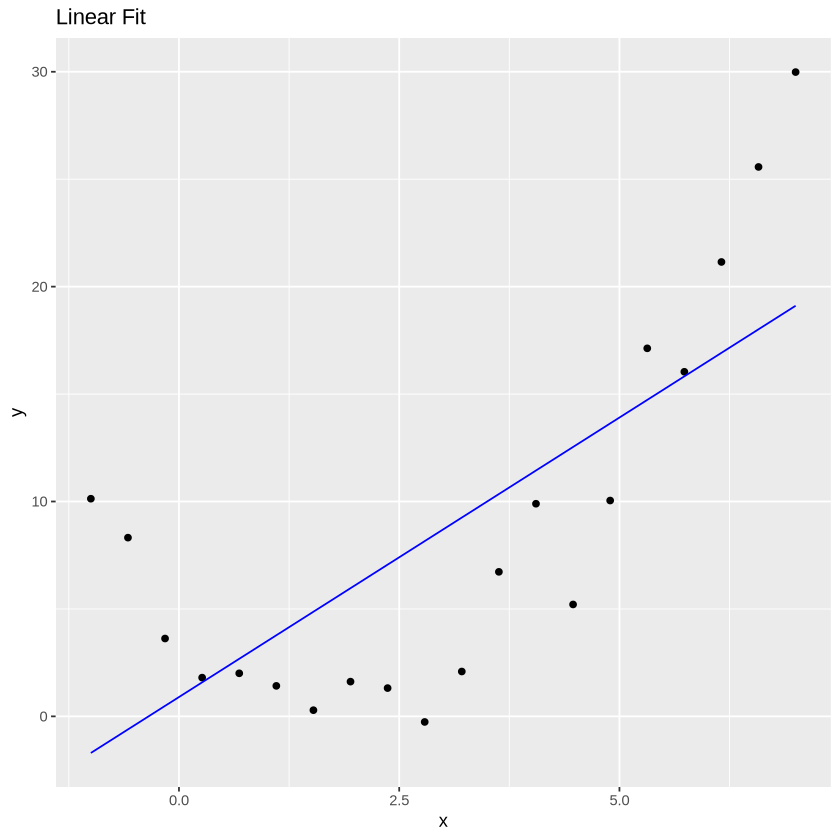

In [24]:
fit1 <- lm(y ~ x, data = dt)

# Plot the fitted line from the linear model

dt |> ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_line(aes(y = predict(fit1)), color = "blue") +
    labs(title = "Linear Fit")

In [25]:
fit_lspline <- lm(y ~ x + x01 + x12, data = dt)

fit_lspline |> summary()


Call:
lm(formula = y ~ x + x01 + x12, data = dt)

Residuals:
   Min     1Q Median     3Q    Max 
-6.160 -1.301  0.405  1.304  4.344 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)    3.573      1.889   1.892   0.0767 .  
x             -6.846      3.362  -2.036   0.0586 .  
x01            3.756      4.271   0.879   0.3922    
x12            8.739      1.576   5.544 4.45e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.732 on 16 degrees of freedom
Multiple R-squared:  0.9209,	Adjusted R-squared:  0.9061 
F-statistic: 62.09 on 3 and 16 DF,  p-value: 4.932e-09


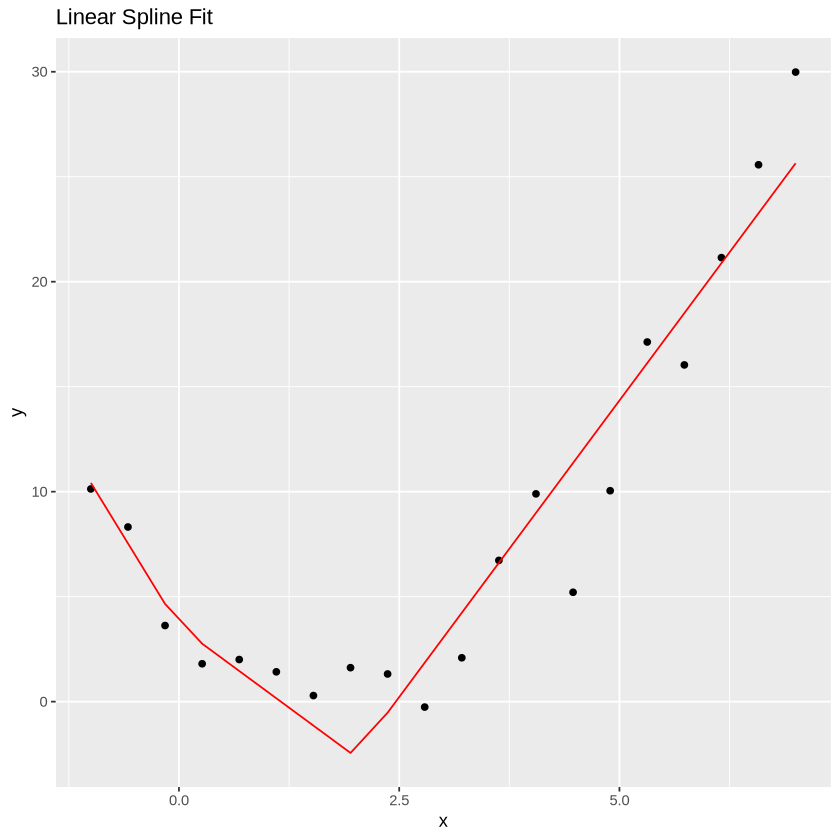

In [30]:
# Plot the fitted line from the linear spline model

dt |> ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_line(aes(y = predict(fit_lspline)), color = "red") +
    labs(title = "Linear Spline Fit")

In [32]:
library(lspline)

fit_lspline1 <- lm(y ~ lspline(x, c(0, 2), marginal = FALSE), data = dt)

fit_lspline1 |> summary()


Call:
lm(formula = y ~ lspline(x, c(0, 2), marginal = FALSE), data = dt)

Residuals:
   Min     1Q Median     3Q    Max 
-6.160 -1.301  0.405  1.304  4.344 

Coefficients:
                                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)                              3.5734     1.8887   1.892   0.0767 .  
lspline(x, c(0, 2), marginal = FALSE)1  -6.8457     3.3621  -2.036   0.0586 .  
lspline(x, c(0, 2), marginal = FALSE)2  -3.0897     1.2714  -2.430   0.0272 *  
lspline(x, c(0, 2), marginal = FALSE)3   5.6494     0.4552  12.410 1.26e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.732 on 16 degrees of freedom
Multiple R-squared:  0.9209,	Adjusted R-squared:  0.9061 
F-statistic: 62.09 on 3 and 16 DF,  p-value: 4.932e-09


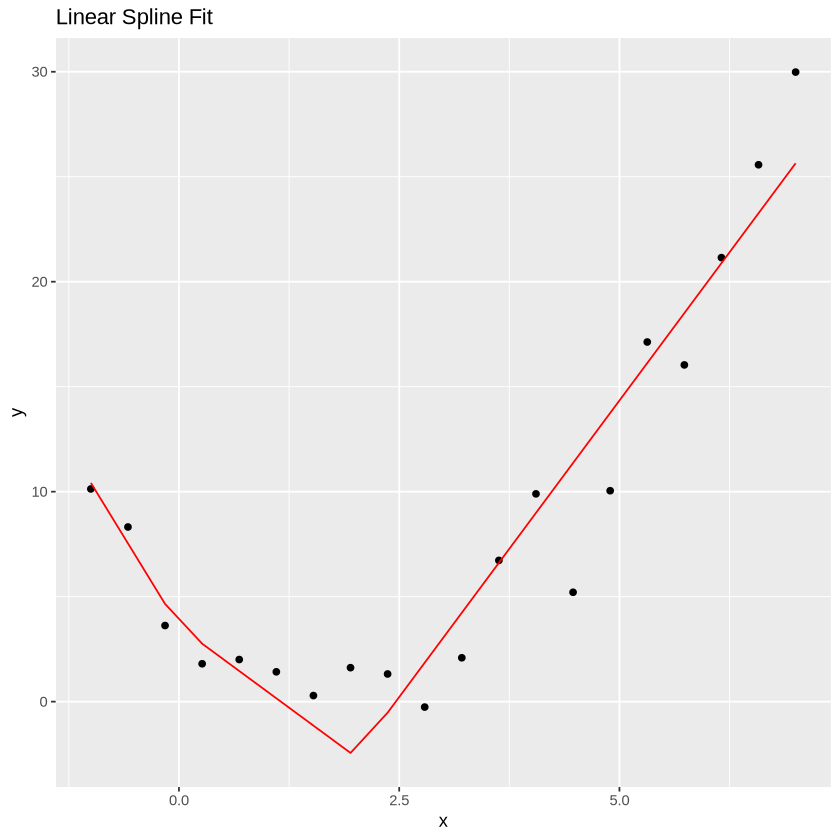

In [33]:
# Plot the fitted line from the linear spline model

dt |> ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_line(aes(y = predict(fit_lspline1)), color = "red") +
    labs(title = "Linear Spline Fit")

In [34]:
fit_lspline1 |> model.matrix()

,(Intercept),"lspline(x, c(0, 2), marginal = FALSE)1","lspline(x, c(0, 2), marginal = FALSE)2","lspline(x, c(0, 2), marginal = FALSE)3"
1,1,-1.0000000,0.0000000,0.0000000
2,1,-0.5789474,0.0000000,0.0000000
3,1,-0.1578947,0.0000000,0.0000000
4,1,0.0000000,0.2631579,0.0000000
5,1,0.0000000,0.6842105,0.0000000
6,1,0.0000000,1.1052632,0.0000000
7,1,0.0000000,1.5263158,0.0000000
8,1,0.0000000,1.9473684,0.0000000
9,1,0.0000000,2.0000000,0.3684211
10,1,0.0000000,2.0000000,0.7894737
